# Check Installation

In [2]:
import f3dasm
assert f3dasm.__version__ == '1.5.4', "Your version of f3dasm is incorrect, please update it."

In [3]:
# Importing some libraries

from IPython.display import display
import pandas as pd
from tabulate import tabulate

# 3D Case

## Data Characterization

### Indicating bounds

In [4]:
from f3dasm import ExperimentData

# Load data from a CSV file
csv_file_path = "./"
data_csv = ExperimentData.from_file(csv_file_path)

# Load data from a PKL file
#pkl_file_path = "experiment_data/domain.pkl"
#data_pkl = ExperimentData.from_pickle(pkl_file_path)

# Access data attributes
input_data_3d, output_data_3d = data_csv.to_pandas()
#print(data_pkl)  # Access loaded data from PKL


In [5]:

output_data_3d['coilable_binary'] = 1* (output_data_3d['coilable'] > 0)
#print(output_data_3d)
data_csv = ExperimentData(input_data=input_data_3d, output_data=output_data_3d)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Creating a function to summarize the data and then plot
def summarize_and_plot(data, sz=None):
    summary = pd.DataFrame({
        '#points': len(data),
        'mean': data.mean(),
        'std': data.std(),
        '0%': data.min(),
        '25%': data.quantile(0.25),
        '50%': data.median(),
        '75%': data.quantile(0.75),
        '99.7%': data.quantile(0.997),
        '100%': data.max(),
        'nan_count': data.isna().sum()
    })

    # Plot quartiles for each column
    if sz == None:
        sz = [len(data.columns), 1]
    fig, axes = plt.subplots(nrows=sz[0], ncols=sz[1], figsize=(np.ceil(8/sz[0]), 
                                                                np.ceil(5/sz[1])))
    if len(data.columns) == 1:
        axes = [axes]
    
    for i, col in enumerate(data.columns):
        ax = axes[i]
        ax.boxplot(data[col].dropna())
        ax.set_title(f'{col} Quartiles')
        ax.set_xticks([])
        ax.set_ylabel(col)

    plt.tight_layout()
    plt.show()
    
    return summary


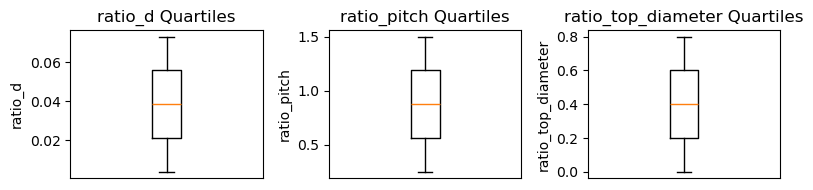

,#points,mean,std,0%,25%,50%,75%,99.7%,100%,nan_count
ratio_d,1000,0.038481,0.019928,0.004,0.021233,0.038466,0.055699,0.072731,0.072933,0
ratio_pitch,1000,0.8746,0.36101,0.25,0.562195,0.87439,1.186584,1.495121,1.498779,0
ratio_top_diameter,1000,0.399644,0.231048,0.0,0.199805,0.399609,0.599414,0.796877,0.799219,0


In [7]:
summarize_and_plot(input_data_3d, (1, 3))

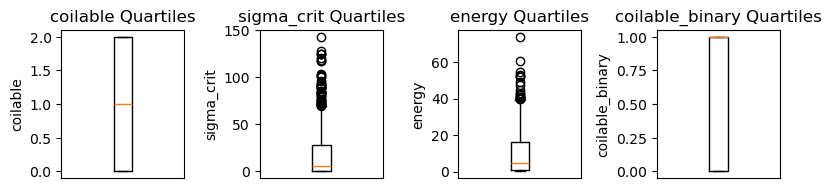

,#points,mean,std,0%,25%,50%,75%,99.7%,100%,nan_count
coilable,1000,1.15,0.874222,0,0.0,1.0,2.0,2.0,2,0
sigma_crit,1000,18.572439,25.177464,0.000494,0.558952,6.20335,28.341039,124.732153,143.264914,51
energy,1000,10.212722,12.659462,0.00028,0.624001,4.586051,16.157745,57.259949,73.917332,476
coilable_binary,1000,0.682,0.465932,0,0.0,1.0,1.0,1.0,1,0


In [8]:
summarize_and_plot(output_data_3d, (1, 4))

In [9]:
data_csv.domain

Domain(space={'ratio_d': _CategoricalParameter(_type='object', categories=[0.004, 0.0384999999999999, 0.0557499999999999, 0.0212499999999999, 0.0298749999999999, 0.0643749999999999, 0.047125, 0.0126249999999999, 0.0169374999999999, 0.0514375, 0.0686875, 0.0341874999999999, 0.0255625, 0.0600624999999999, 0.0428124999999999, 0.0083125, 0.0104687499999999, 0.04496875, 0.0622187499999999, 0.0277187499999999, 0.0363437499999999, 0.07084375, 0.0535937499999999, 0.01909375, 0.01478125, 0.04928125, 0.06653125, 0.03203125, 0.0234062499999999, 0.0579062499999999, 0.0406562499999999, 0.00615625, 0.0072343749999999, 0.0417343749999999, 0.0589843749999999, 0.024484375, 0.0331093749999999, 0.067609375, 0.050359375, 0.015859375, 0.020171875, 0.0546718749999999, 0.071921875, 0.0374218749999999, 0.0287968749999999, 0.0632968749999999, 0.046046875, 0.0115468749999999, 0.009390625, 0.0438906249999999, 0.0611406249999999, 0.0266406249999999, 0.0352656249999999, 0.069765625, 0.0525156249999999, 0.018015625

### Scatter plots

In [10]:
import itertools

def scatter_pairs(df):
    df = df.iloc[:100]
    pairs = list(itertools.combinations(df.columns, 2))
    fs = 18
    fig, axes = plt.subplots(len(pairs), 1, figsize=(6, 4 * len(pairs)), squeeze=True)
    for (x, y), ax in zip(pairs, axes.flatten()):
        ax.scatter(df[x], df[y], s=5)
        ax.set_xlabel(x, fontsize=fs)
        ax.set_ylabel(y, fontsize=fs)
        title = f'{x} vs {y}'
        ax.set_title(title, fontsize=fs)
        ax.tick_params(axis='both', labelsize=fs)
        
        #ax.axhline(y=ax.get_xlim()[0], color='gray', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()


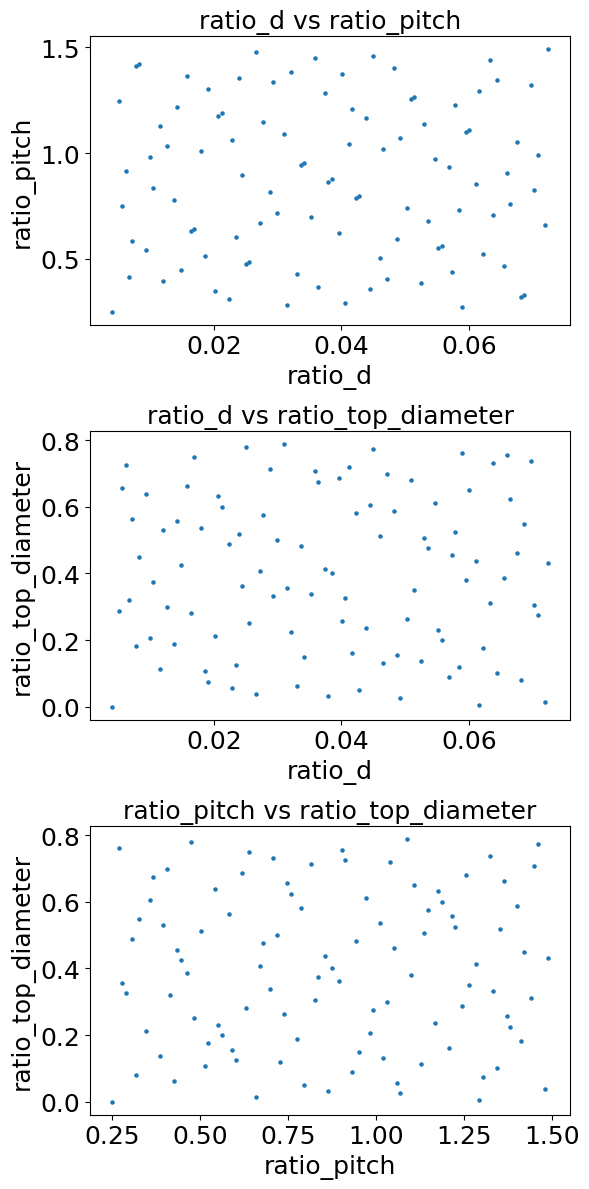

In [11]:
scatter_pairs(input_data_3d)

In [12]:
def plot_3d_scatter(df):
    from mpl_toolkits.mplot3d import Axes3D
    df = df.iloc[:100]
    fs = 12
    fig = plt.figure(figsize=(9, 6.5))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(df.iloc[:, 0], df.iloc[:, 1], df.iloc[:, 2], s=20, alpha=0.8)
    ax.set_xlabel(df.columns[0], fontsize=fs)
    ax.set_ylabel(df.columns[1], fontsize=fs)
    ax.set_zlabel(df.columns[2], fontsize=fs)
    ax.set_title('3D Scatter plot', fontsize=fs)
    ax.tick_params(axis='both', labelsize=fs)
    plt.tight_layout()
    plt.show()

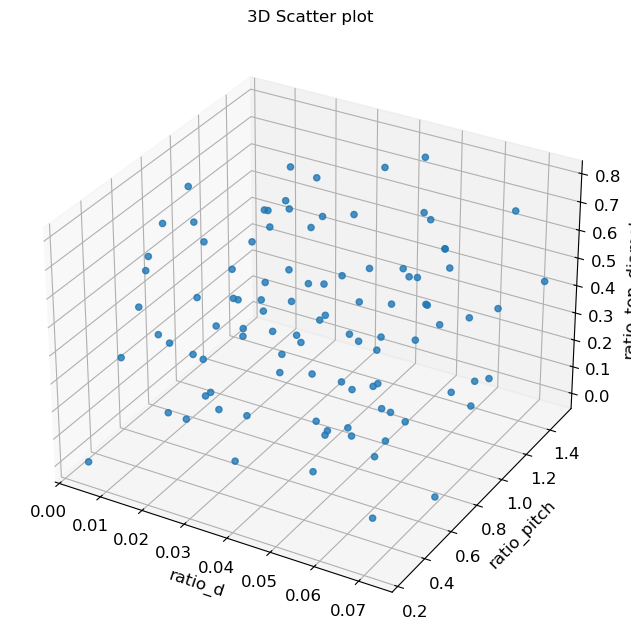

In [13]:
plot_3d_scatter(input_data_3d)

### Histograms

In [14]:
def plot_histograms(data, bins=20, sz=None):
    if sz is None:
        sz = [len(data.columns), 1]
    fig, axes = plt.subplots(nrows=sz[0], ncols=sz[1], figsize=(np.ceil(12 / sz[0]), 
                                                                np.ceil(8 / sz[1])))
    if len(data.columns) == 1:
        axes = [axes]

    for i, col in enumerate(data.columns):
        ax = axes[i]
        ax.hist(data[col].dropna(), bins=bins, alpha=0.7, color='blue')
        ax.set_title(f'{col} variable')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()


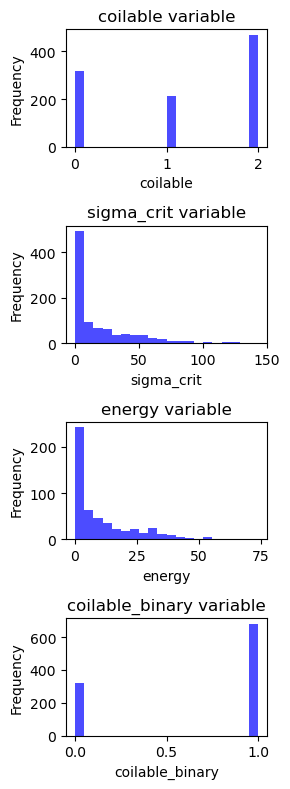

In [15]:
plot_histograms(output_data_3d)

In [16]:
# Removing 3 sigma values for both
data_csv = data_csv.select((output_data_3d['energy'] <= 57.27) | (output_data_3d['sigma_crit'] <= 124.73))
#output_data_3d = output_data_3d.loc[output_data_3d['sigma_crit'] <= 124.73, :]
#output_data_3d = output_data_3d.loc[output_data_3d['energy'] <= 57.27, :]

summary = pd.DataFrame({
        '0 (not coilable)': output_data_3d.eq(0).sum(),
        '1 (Coilable)': output_data_3d.eq(1).sum(),
        '2 (Coilable but yields)': output_data_3d.eq(2).sum(),
    })

print(summary.iloc[0])

0 (not coilable)           318
1 (Coilable)               214
2 (Coilable but yields)    468
Name: coilable, dtype: int64


### Maximum reversible coilable value

In [17]:
subset = output_data_3d['coilable'] == 1

max_crit_stress_idx = output_data_3d.loc[subset, 'sigma_crit'].idxmax()
print('Maximum stress feature values:')
print(input_data_3d.iloc[max_crit_stress_idx, :])
print('Maximum stress output values:')
print(output_data_3d.iloc[max_crit_stress_idx, :])
print("--------")
max_energy_dx = output_data_3d.loc[subset, 'energy'].idxmax()
print('Maximum energy feature values:')
print(input_data_3d.iloc[max_energy_dx, :])
print('Maximum energy output values:')
print(output_data_3d.iloc[max_energy_dx, :])




Maximum stress feature values:
ratio_d               0.071989
ratio_pitch           0.976318
ratio_top_diameter    0.477344
Name: 981, dtype: object
Maximum stress output values:
coilable                   1
sigma_crit         93.408673
energy                   NaN
coilable_binary            1
Name: 981, dtype: object
--------
Maximum energy feature values:
ratio_d               0.033783
ratio_pitch           0.320801
ratio_top_diameter    0.757812
Name: 420, dtype: object
Maximum energy output values:
coilable                  1
sigma_crit         6.735183
energy             3.732142
coilable_binary           1
Name: 420, dtype: object


## Training models

In [18]:
from sklearn.metrics import accuracy_score
from f3dasm.datageneration import DataGenerator
from f3dasm.design import make_nd_continuous_domain
from f3dasm import ExperimentData
from typing import Optional
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from f3dasm._src.datageneration.functions import Function
import f3dasm_optimize
import copy


class ModelEvaluator(DataGenerator):
    def __init__(self, data, sz= None):
        Xs, Ys = data.to_pandas()
        Xs = Xs.sort_index(); Ys = Ys.sort_index(); 
        X_train, x_test = train_test_split(Xs, random_state=123)
        Y_train, y_test = train_test_split(Ys, random_state=123)
        
        self.X_train = X_train
        self.y_train = Y_train
        self.X_test = x_test
        self.y_test = y_test
        if sz is None:
            sz = Y_train.shape[0]
        self.training_points = sz
        
    def fit_model(self, model, output_variable, scaler = StandardScaler, sz = None, classification = True):
        if sz == None:
            sz = self.training_points
        Y_train = np.array(self.y_train.loc[:, output_variable], dtype=np.float64)
        indices = np.flatnonzero(~np.isnan(Y_train))[:sz]
        X_train = np.array(self.X_train, dtype=np.float64)
        Y_train = Y_train[indices]; X_train = X_train[indices]
        scaler_x = scaler() # Scaling inputs with the Scaler provided:
        scaler_x.fit(X_train) # fit the scaler to the input data
        X_train_scaled=scaler_x.transform(X_train) # scale the input training data
        
        # Scale outputs:
        if classification == True:
            y_train_scaled = Y_train.astype(int)
            scaler_y = scaler()
            scaler_y.transform = lambda x: x
            scaler_y.inverse_transform = lambda x: x
        
        else:
            scaler_y = scaler()
            scaler_y.fit(Y_train.reshape(-1, 1)) # fit the scaler to the output data
            y_train_scaled=scaler_y.transform(Y_train.reshape(-1, 1)) # scale the output training data

        model.fit(X_train_scaled, y_train_scaled)
        
        def predictor(X_query):
            try:
                X_query_scaled = scaler_x.transform(X_query)
            except:
                X_query_scaled = scaler_x.transform(np.array([X_query]).reshape(1, -1))
                
            return scaler_y.inverse_transform(model.predict(X_query_scaled).reshape(-1, 1))
        
        return predictor, model
    
    def evaluate_metric(self, model, output_variable, metrics: dict = {}, sz = None, classification=True):
        # Evaluates the predictor of y_values under the metric provided
        predictor, _ = self.fit_model(model, output_variable, sz=sz, classification=classification)
        target_variable = self.y_test[output_variable]
        indices = ~target_variable.isna()
        target_variable = target_variable[indices]
        if classification==True:
            target_variable = target_variable.astype(int)
        
        return {metric:(metrics[metric](predictor(np.array(self.X_test[indices], 
                                                           dtype=np.float64)), target_variable))
                for metric in metrics}
    
    def hyperparameter_optimization(self, base_model, domain, output_variable: str,
                                    metric, 
                                    optimizer: str = 'Nelder-Mead', iterations=100,
                                   classification=True):
        # Performs hyperparameter optimization on the base model provided, by varing 
        # the hyperparameters specified in the domain and evaluating under the metric
        

        # Create an empty ExperimentData object from the domain
        data = ExperimentData(domain=domain)
        # Set the kwargs for the data generator
        kwargs= {'scale_bounds': domain.get_bounds(), 'offset': False}
        
        # Defining the objective function
        objective_function = Function()
        def fn(inputs):
            #x = np.sum(inputs**2)
            #return (np.sin(x)*x)**2
            model = copy.copy(base_model)
            valdicts = {key:val for key, val in zip(domain.names, inputs)}
            if callable(base_model):
                model = model(valdicts)
            else:
                # Modify models with new hyperparameters

                model.set_params(**valdicts)
            result = self.evaluate_metric(model=model, output_variable=output_variable,
                                        metrics = {"obj_fn":metric}, classification=classification)
            return result['obj_fn']
        
        objective_function.evaluate = fn;
        # Optimize the benchmark function with the given optimizer
        # The x0 selection strategy is set to 'new', hence first sampling new candidate(s) as a starting point
        data.optimize(optimizer=optimizer, data_generator=objective_function, kwargs=kwargs, 
                  iterations=iterations, x0_selection='new', hyperparameters={'seed':123})

        # Return the data
        return data

def display_model_params(mod, chunk_size=6):
    S = {k: str(v) for k, v in mod.get_params().items()}
    for i in range(0, len(S), chunk_size):
        display(pd.DataFrame({k: S[k] for k in list(S)[i:i+chunk_size]}, index=[0]))


### Fitting C-SVC, KNeighbors and Random Forest

In [19]:
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn import svm
from sklearn.gaussian_process.kernels import RBF, Matern
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

param_grid_SVC = {
    'simpleimputer__strategy': ['mean', 'median'],  # Options for SimpleImputer
    'svc__C': [0.1, 1, 10, 100],                       # Hyperparameters for SVC
    'svc__kernel': ['linear', 'rbf'],              # Try different kernels
    'svc__gamma': ['scale', 'auto'],               # Kernel-specific hyperparameters
}
param_grid_RFC= {
    'n_estimators': [100, 200],             # Number of trees
    'max_depth': [None, 10],                # Maximum depth of trees
    'min_samples_split': [2, 5],            # Minimum samples to split a node
}
#     'n_estimators': [100, 200, 500],             # Number of trees in the forest
#     'max_depth': [None, 10, 20, 30],             # Maximum depth of each tree
#     'min_samples_split': [2, 5, 10],             # Minimum samples to split an internal node
#     'min_samples_leaf': [1, 2, 5],               # Minimum samples in a leaf node
#     'max_features': ['sqrt', 'log2', None],      # Number of features to consider for splits
#     'bootstrap': [True, False],                  # Whether to use bootstrapping
# }

param_grid_GradientBoostClassifier = {
    'learning_rate': [0.05, 0.1],             # Step size at each iteration
    'max_iter': [100, 200],                   # Number of boosting iterations
    'max_depth': [None, 10],                  # Maximum depth of each tree
}
#     'learning_rate': [0.01, 0.1, 0.2],            # Learning rate #'max_iter': [100, 200, 300],                  # Number of boosting iterations
#     'max_depth': [None, 5, 10],                   # Maximum depth of each tree
#     'min_samples_leaf': [10, 20, 50],             # Minimum samples per leaf
#     'l2_regularization': [0, 0.1, 1.0],           # L2 regularization strength
#     'max_bins': [255, 512],                       # Maximum number of bins for histogram
# }
models_classifier = (
    {
        'name': 'SVC', 
        'model': GridSearchCV(make_pipeline(
                                        SimpleImputer(strategy='mean'),   # Impute missing values with the mean
                                        StandardScaler(),                 # Standardize the features
                                        svm.SVC(class_weight='balanced')                              # SVC model
                                        ), param_grid_SVC, cv=5), 
        'output_variable':'coilable'
    },
    {
        'name': 'KNN',
         'model': KNeighborsClassifier(5), 
         'output_variable':'coilable'
    },
    {
        'name': 'RandomForestGridSearch', 
        'model':GridSearchCV(estimator=RandomForestClassifier(),
                             param_grid=param_grid_RFC,
                             cv=5,
                             scoring='accuracy'),
        'output_variable': 'coilable'
    },
    {
        'name': 'GradientBoost', 
        'model':GridSearchCV(estimator=HistGradientBoostingClassifier(), 
                             param_grid=param_grid_GradientBoostClassifier, 
                             cv=5,
                             scoring='accuracy'), 
        'output_variable':'coilable'
    }
)   

models = []
perfs = {
    'accuracy': accuracy_score, 
    'f1': lambda x, y: f1_score(x, y, average='weighted', zero_division=0), 
    'precision': lambda x, y: precision_score(x, y, average='weighted', zero_division=0), 
    'recall': lambda x, y: recall_score(x, y, average='weighted', zero_division=0)
}

classifier = ModelEvaluator(data_csv)

for model in models_classifier:
    predictor, mod = classifier.fit_model(model['model'], output_variable=model['output_variable'])
    perfs_model = classifier.evaluate_metric(mod, model['output_variable'], metrics=perfs)
    models.append(mod)
    print(f"Model: {model['model']}")
    try:
        print(f"Best parameters: {mod.best_params_}")
    except:
        None
    #display_model_params(mod)
    #display(pd.DataFrame(mod.get_params(), index=[0]))
    #display(pd.DataFrame(mod.coefs_, index=[0]))
    display(pd.DataFrame(perfs_model, index=[0]))

    

Model: GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('simpleimputer', SimpleImputer()),
                                       ('standardscaler', StandardScaler()),
                                       ('svc', SVC(class_weight='balanced'))]),
             param_grid={'simpleimputer__strategy': ['mean', 'median'],
                         'svc__C': [0.1, 1, 10, 100],
                         'svc__gamma': ['scale', 'auto'],
                         'svc__kernel': ['linear', 'rbf']})
Best parameters: {'simpleimputer__strategy': 'mean', 'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}


,accuracy,f1,precision,recall
0,0.890295,0.888466,0.894758,0.890295


Model: KNeighborsClassifier()


,accuracy,f1,precision,recall
0,0.890295,0.889907,0.892731,0.890295


Model: GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


,accuracy,f1,precision,recall
0,0.924051,0.925437,0.928149,0.924051


Model: GridSearchCV(cv=5, estimator=HistGradientBoostingClassifier(),
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [None, 10],
                         'max_iter': [100, 200]},
             scoring='accuracy')
Best parameters: {'learning_rate': 0.05, 'max_depth': None, 'max_iter': 100}


,accuracy,f1,precision,recall
0,0.936709,0.938923,0.943782,0.936709


In [20]:
print(mod.best_params_)

{'learning_rate': 0.05, 'max_depth': None, 'max_iter': 100}


## Two-class classification

In [21]:
output_variable = 'coilable_binary'
models_classifier = (
    {
        'name': 'SVC', 
        'model': svm.SVC(random_state=123), 
        'output_variable':output_variable
    },
    {
        'name': 'KNN', 
        'model': KNeighborsClassifier(5), 
        'output_variable':output_variable
    },
    {
        'name': 'RandomForest', 
        'model':RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1, random_state=123),
        'output_variable': output_variable
    },
    {
        'name': 'GradientBoost', 
        'model':HistGradientBoostingClassifier(), 
        'output_variable':output_variable
    }
)   

models = []
perfs = {
    'accuracy': accuracy_score, 
    'f1': lambda x, y: f1_score(x, y, average='weighted', zero_division=1), 
    'precision': lambda x, y: precision_score(x, y, average='weighted', zero_division=1), 
    'recall': lambda x, y: recall_score(x, y, average='weighted', zero_division=1)
}

classifier = ModelEvaluator(data_csv)

for model in models_classifier:
    predictor, mod = classifier.fit_model(model['model'], output_variable=model['output_variable'])
    perfs_model = classifier.evaluate_metric(mod, model['output_variable'], metrics=perfs)
    models.append(predictor)
    print(f"Model: {model['model']}")
    print(f"Number of training points: {len(classifier.X_train)}")
    print(f"Number of testing points: {len(classifier.X_test)}")
    #display_model_params(mod)
    #display(pd.DataFrame(mod.get_params(), index=[0]))
    #display(pd.DataFrame(mod.coefs_, index=[0]))
    display(pd.DataFrame(perfs_model, index=[0]))

    

Model: SVC(random_state=123)
Number of training points: 708
Number of testing points: 237


,accuracy,f1,precision,recall
0,0.983122,0.983067,0.983171,0.983122


Model: KNeighborsClassifier()
Number of training points: 708
Number of testing points: 237


,accuracy,f1,precision,recall
0,0.962025,0.961962,0.961938,0.962025


Model: RandomForestClassifier(max_depth=5, max_features=1, n_estimators=10,
                       random_state=123)
Number of training points: 708
Number of testing points: 237


,accuracy,f1,precision,recall
0,0.962025,0.962523,0.964909,0.962025


Model: HistGradientBoostingClassifier()
Number of training points: 708
Number of testing points: 237


,accuracy,f1,precision,recall
0,0.995781,0.995774,0.995807,0.995781


## Regression problems

### Fitting GPR, ..., ...

### Energy fitting

In [22]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression # For Least Squares Regression
from sklearn.preprocessing import PolynomialFeatures # For Polynomial basis functions
from sklearn.pipeline import make_pipeline # to link different objects

models_regressor = (
    {
        'name': 'GPRMatern',  
        'model': GaussianProcessRegressor(
            Matern(nu=2.5), 
            alpha=1e-4, 
            n_restarts_optimizer=20, 
            random_state=123), 
        'output_variable':'energy'
    },
    {
        'name': 'RFRegressor', 
        'model': RandomForestRegressor(
            max_depth=2, 
            random_state=123), 
        'output_variable':'energy'},
    {
        'name': 'ElasticNet', 
        'model': make_pipeline(
            PolynomialFeatures(degree=3), 
            ElasticNet(random_state=123, max_iter=1_000)), 
        'output_variable': 'energy'
    }
)
    #{'name': 'KNN', 'model': KNeighborsClassifier(5), 'output_variable':'coilable'},
    #{'name': 'GPC', 'model':RandomForestClassifier(
    #    max_depth=5, n_estimators=10, max_features=1, random_state=123),
    # 'output_variable': 'coilable'}
#)
models = []
perfs = {'r2': r2_score, 
         'MSE': mean_squared_error
        }

for model in models_regressor:
    predictor, mod = classifier.fit_model(model['model'], output_variable=model['output_variable'], classification=False)
    perfs_model = classifier.evaluate_metric(mod, model['output_variable'], metrics=perfs, classification=False)
    models.append(predictor)
    print(f"Model: {model['model']}")
    print(f"Number of training points: {len(classifier.X_train)}")
    print(f"Number of testing points: {len(classifier.X_test)}")
    #display_model_params(mod)
    display(pd.DataFrame(perfs_model, index=[0]))


Model: GaussianProcessRegressor(alpha=0.0001, kernel=Matern(length_scale=1, nu=2.5),
                         n_restarts_optimizer=20, random_state=123)
Number of training points: 708
Number of testing points: 237


,r2,MSE
0,0.997532,0.44475


/Users/eaguerov/mambaforge/envs/3dasm/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/eaguerov/mambaforge/envs/3dasm/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model: RandomForestRegressor(max_depth=2, random_state=123)
Number of training points: 708
Number of testing points: 237


,r2,MSE
0,0.873339,18.049517


Model: Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('elasticnet', ElasticNet(random_state=123))])
Number of training points: 708
Number of testing points: 237


,r2,MSE
0,-1.257425,80.580438


### $\sigma_{crit}$ fitting

In [23]:
output_variable = 'sigma_crit'
models_regressor = (
    {
        'name': 'GPRMatern',  
        'model': GaussianProcessRegressor(
            Matern(nu=2.5), 
            alpha=1e-4, 
            n_restarts_optimizer=20, 
            random_state=123), 
        'output_variable':output_variable
    },
    {
        'name': 'RFRegressor', 
        'model': RandomForestRegressor(max_depth=2, random_state=123), 
        'output_variable':output_variable
    },
    {
        'name': 'ElasticNet', 
        'model': make_pipeline(
            PolynomialFeatures(degree=3), 
            ElasticNet(random_state=123, max_iter=1_000)), 
        'output_variable': output_variable
    }
)
    #{'name': 'KNN', 'model': KNeighborsClassifier(5), 'output_variable':'coilable'},
    #{'name': 'GPC', 'model':RandomForestClassifier(
    #    max_depth=5, n_estimators=10, max_features=1, random_state=123),
    # 'output_variable': 'coilable'}
#)
models = []
perfs = {'r2': r2_score, 
         'MSE': mean_squared_error
        }

for model in models_regressor:
    predictor, mod = classifier.fit_model(model['model'], output_variable=model['output_variable'], classification=False)
    perfs_model = classifier.evaluate_metric(mod, model['output_variable'], metrics=perfs, classification=False)
    models.append(predictor)
    print(f"Model: {model['model']}")
    print(f"Number of training points: {len(classifier.X_train)}")
    print(f"Number of testing points: {len(classifier.X_test)}")
    display_model_params(mod)
    display(pd.DataFrame(perfs_model, index=[0]))


Model: GaussianProcessRegressor(alpha=0.0001, kernel=Matern(length_scale=1, nu=2.5),
                         n_restarts_optimizer=20, random_state=123)
Number of training points: 708
Number of testing points: 237


,alpha,copy_X_train,kernel__length_scale,kernel__length_scale_bounds,kernel__nu,kernel
0,0.0001,True,1.0,"(1e-05, 100000.0)",2.5,"Matern(length_scale=1, nu=2.5)"


,n_restarts_optimizer,n_targets,normalize_y,optimizer,random_state
0,20,None,False,fmin_l_bfgs_b,123


,r2,MSE
0,0.999444,0.346853


/Users/eaguerov/mambaforge/envs/3dasm/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/eaguerov/mambaforge/envs/3dasm/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


...

,memory,steps,verbose,polynomialfeatures,elasticnet,polynomialfeatures__degree
0,None,"[('polynomialfeatures', PolynomialFeatures(deg...",False,PolynomialFeatures(degree=3),ElasticNet(random_state=123),3


,polynomialfeatures__include_bias,polynomialfeatures__interaction_only,polynomialfeatures__order,elasticnet__alpha,elasticnet__copy_X,elasticnet__fit_intercept
0,True,False,C,1.0,True,True


,elasticnet__l1_ratio,elasticnet__max_iter,elasticnet__positive,elasticnet__precompute,elasticnet__random_state,elasticnet__selection
0,0.5,1000,False,False,123,cyclic


,elasticnet__tol,elasticnet__warm_start
0,0.0001,False


,r2,MSE
0,-0.878031,264.391946


## Evaluating the best machine models found

### Influence of number of training points

#### Classification problem:

In [24]:
output_variable = 'coilable'
SVCModel = {
    'name': 'SVC', 
    'model': svm.SVC(random_state=123), 
    'output_variable':output_variable
}
number_of_training_points = [100*i for i in range(1, 6)]
models = []
perfs = {'accuracy': accuracy_score, 
         'f1': lambda x, y: f1_score(x, y, average='weighted', zero_division=1), 
         'precision': lambda x, y: precision_score(x, y, average='weighted', zero_division=1), 
         'recall': lambda x, y: recall_score(x, y, average='weighted', zero_division=1)}

classifier = ModelEvaluator(data_csv)

for nb in number_of_training_points:
    predictor, mod = classifier.fit_model(SVCModel['model'], output_variable=SVCModel['output_variable'], sz=nb) 
    perfs_model = classifier.evaluate_metric(mod, SVCModel['output_variable'], metrics=perfs, sz = nb)
    models.append(predictor)
    print(f"Model: {model['model']}")
    print(f"Number of training points: {nb}")
    print(f"Number of testing points: {len(classifier.X_test)}")
    #display_model_params(mod)
    #display(pd.DataFrame(mod.get_params(), index=[0]))
    #display(pd.DataFrame(mod.coefs_, index=[0]))
    display(pd.DataFrame(perfs_model, index=[0]))

    

Model: Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('elasticnet', ElasticNet(random_state=123))])
Number of training points: 100
Number of testing points: 237


,accuracy,f1,precision,recall
0,0.877637,0.877737,0.877879,0.877637


Model: Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('elasticnet', ElasticNet(random_state=123))])
Number of training points: 200
Number of testing points: 237


,accuracy,f1,precision,recall
0,0.877637,0.876791,0.877083,0.877637


Model: Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('elasticnet', ElasticNet(random_state=123))])
Number of training points: 300
Number of testing points: 237


,accuracy,f1,precision,recall
0,0.894515,0.895715,0.897346,0.894515


Model: Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('elasticnet', ElasticNet(random_state=123))])
Number of training points: 400
Number of testing points: 237


,accuracy,f1,precision,recall
0,0.894515,0.896126,0.898797,0.894515


Model: Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('elasticnet', ElasticNet(random_state=123))])
Number of training points: 500
Number of testing points: 237


,accuracy,f1,precision,recall
0,0.894515,0.89613,0.899167,0.894515


#### Regression problem

In [25]:
output_variable = 'coilable'
GPRModel = {'name': 'GPRMatern',  'model': GaussianProcessRegressor(Matern(nu=2.5), alpha=1e-4, n_restarts_optimizer=20, random_state=123), 
     'output_variable':'energy'}
number_of_training_points = [100*i for i in range(1, 6)]
models = []
perfs = {'accuracy': accuracy_score, 
         'f1': lambda x, y: f1_score(x, y, average='weighted', zero_division=1), 
         'precision': lambda x, y: precision_score(x, y, average='weighted', zero_division=1), 
         'recall': lambda x, y: recall_score(x, y, average='weighted', zero_division=1)}

models = []
perfs = {'r2': r2_score, 
         'MSE': mean_squared_error
        }
for nb in number_of_training_points:
    predictor, mod = classifier.fit_model(GPRModel['model'], output_variable=GPRModel['output_variable'], sz=nb) 
    perfs_model = classifier.evaluate_metric(mod, GPRModel['output_variable'], metrics=perfs, sz = nb)
    models.append(predictor)
    print(f"Model: {model['model']}")
    print(f"Number of training points: {nb}")
    print(f"Number of testing points: {len(classifier.X_test)}")
    display_model_params(mod)
    #display(pd.DataFrame(mod.get_params(), index=[0]))
    #display(pd.DataFrame(mod.coefs_, index=[0]))
    display(pd.DataFrame(perfs_model, index=[0]))

    

Model: Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('elasticnet', ElasticNet(random_state=123))])
Number of training points: 100
Number of testing points: 237


,alpha,copy_X_train,kernel__length_scale,kernel__length_scale_bounds,kernel__nu,kernel
0,0.0001,True,1.0,"(1e-05, 100000.0)",2.5,"Matern(length_scale=1, nu=2.5)"


,n_restarts_optimizer,n_targets,normalize_y,optimizer,random_state
0,20,None,False,fmin_l_bfgs_b,123


,r2,MSE
0,0.83976,20.146459


Model: Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('elasticnet', ElasticNet(random_state=123))])
Number of training points: 200
Number of testing points: 237


...

,r2,MSE
0,0.973576,4.139955


Model: Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('elasticnet', ElasticNet(random_state=123))])
Number of training points: 500
Number of testing points: 237


,alpha,copy_X_train,kernel__length_scale,kernel__length_scale_bounds,kernel__nu,kernel
0,0.0001,True,1.0,"(1e-05, 100000.0)",2.5,"Matern(length_scale=1, nu=2.5)"


,n_restarts_optimizer,n_targets,normalize_y,optimizer,random_state
0,20,None,False,fmin_l_bfgs_b,123


,r2,MSE
0,0.973576,4.139955


## Hyperparameter optimization example

In [26]:
from f3dasm.design import Domain
dataModel = ModelEvaluator(data_csv)
metric = lambda x, y: 1-accuracy_score(x, y) # to get to zero
hyper_domain = Domain(); hyper_domain.add_float('C', low = 1e-3, high = 1000)
SVC_data = dataModel.hyperparameter_optimization(SVCModel['model'], hyper_domain, optimizer='TPESampler',
                                                 output_variable='coilable', metric=metric)
print(SVC_data)
print(SVC_data.get_n_best_output(3))

        jobs       input    output
                       C         y
0   finished  682.352181  0.080169
1   finished  696.469489  0.080169
2   finished  286.140049  0.101266
3   finished  226.852227  0.101266
4   finished  551.315218  0.084388
..       ...         ...       ...
95  finished  814.614555  0.080169
96  finished   700.41232  0.080169
97  finished   728.97147  0.080169
98  finished   766.71072  0.080169
99  finished  923.006844  0.080169

[100 rows x 3 columns]
       jobs       input    output
                      C         y
0  finished  682.352181  0.080169
1  finished  696.469489  0.080169
5  finished   719.46925  0.080169


In [26]:
def model_generator(dictt):
    return GaussianProcessRegressor(Matern(nu=dictt['nu']), alpha=1e-4, n_restarts_optimizer=1, random_state=123, optimizer='fmin_l_bfgs_b') 

hyper_domain = Domain(); hyper_domain.add_float('nu', low = 1e-3, high = 50)
GPR_data = dataModel.hyperparameter_optimization(model_generator, hyper_domain, optimizer='TPESampler',
                                                 output_variable='sigma_crit', metric=mean_squared_error, iterations=30)
print(GPR_data)
print(GPR_data.get_n_best_output(3))

/Users/eaguerov/mambaforge/envs/3dasm/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/eaguerov/mambaforge/envs/3dasm/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/eaguerov/mambaforge/envs/3dasm/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/eaguerov/mambaforge/e

ValueError: Input contains NaN.

# Optimization

In [27]:
# Best SVC
SVC_p4 = svm.SVC(C=682.35, random_state=123);
predictor_SVC, mod_SVC = classifier.fit_model(SVC_p4, output_variable='coilable') 
# Best GPR
GPR_p4 = GaussianProcessRegressor(Matern(nu=2.5), alpha=1e-4, n_restarts_optimizer=10, random_state=123, optimizer='fmin_l_bfgs_b');
predictor_GPR, mod_GPR = dataModel.fit_model(GPR_p4, output_variable='sigma_crit') 

def obj_fn1(x_input):
    #  
    return -(np.abs(np.abs(predictor_SVC(x_input) - 1)-1)* 
             predictor_GPR(x_input)).item()


In [29]:
#print(obj_fn1([0.071, 0.976, 0.477]))
print(f"Previous optimized value on dataset: {obj_fn1([0.071989, 0.976318, 0.477344])}")
#print(predictor_GPR([0.071989, 0.976318, 0.477344]))
print(f"Miguel paper GPR: {obj_fn1([0.0111, 0.1666, 0.666])}") # This is on Miguel's paper
print(f"My optimizer optimum: {obj_fn1([0.072981, 0.89154, 0.608209])}") 
#print(dataModel.evaluate_metric(mod_SVC, 'coilable', metrics={'acc':accuracy_score}))
#print(dataModel.evaluate_metric(mod_GPR, 'sigma_crit', metrics={'mse':mean_squared_error}, classification=False))


Previous optimized value on dataset: -92.99139656886382
Miguel paper GPR: 0.41668980205945233
My optimizer optimum: -117.65914366483258


In [42]:
def optimizer(obj_fn, domain, optimizer: str = 'Nelder-Mead', iterations=100):
    # Performs hyperparameter optimization on the base model provided, by varing 
    # the hyperparameters specified in the domain and evaluating under the metric


    # Create an empty ExperimentData object from the domain
    data = ExperimentData(domain=domain)
    # Set the kwargs for the data generator
    kwargs= {'scale_bounds': domain.get_bounds(), 'offset': False}

    # Defining the objective function
    objective_function = Function()
    objective_function.evaluate = obj_fn;
    # Optimize the benchmark function with the given optimizer
    # The x0 selection strategy is set to 'new', hence first sampling new candidate(s) as a starting point
    data.optimize(optimizer=optimizer, data_generator=objective_function, 
              iterations=iterations, x0_selection='new', hyperparameters={'seed':123})

    # Return the data
    return data


optim_domain = Domain()
optim_domain.add_float('ratio_d', low = 0.004, high = 0.072)
optim_domain.add_float('ratio_pitch', low = 0.25, high = 1.5)
optim_domain.add_float('ratio_top_diameter', low = 1e-7, high = 0.8)

results = optimizer(obj_fn1, optim_domain, optimizer='TPESampler', iterations=1000)

results.get_n_best_output(5)

jobs     input                                     output
                ratio_d ratio_pitch ratio_top_diameter           y
990  finished  0.071975    0.736428           0.662001 -123.619486
963  finished   0.07199    0.777977           0.659889 -122.610992
885  finished  0.071973    0.779995           0.653419 -121.695526
888  finished  0.071974    0.777277           0.651922 -121.547983
988  finished   0.07199    0.762588           0.648445 -121.358019

In [31]:
print(results.get_n_best_output(30))

         jobs     input                                     output
                ratio_d ratio_pitch ratio_top_diameter           y
737  finished  0.072973    0.760199            0.65304 -126.193352
622  finished  0.072975    0.772397           0.651623 -125.834009
983  finished  0.072992    0.761427           0.644909 -125.110685
656  finished   0.07294    0.777416           0.644562 -124.635627
502  finished  0.072938    0.768039           0.643315 -124.570274
419  finished   0.07296    0.812135           0.646031 -124.419286
537  finished  0.072948    0.790928           0.643704 -124.361921
541  finished  0.072938    0.794651           0.643921 -124.302018
530  finished  0.072895    0.803275            0.64507 -124.170112
978  finished  0.072974    0.762063           0.638958 -124.117122
467  finished  0.071719    0.723582           0.672863  -124.05152
895  finished  0.072965    0.815447           0.643336 -124.014853
988  finished   0.07299    0.798663           0.640886 -124.00

/var/folders/fy/v5bg020j3xn0415lw8wxppjh0000gn/T/ipykernel_5622/3496861068.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sizes = output_df.loc[:, size_column].fillna(10)


<IPython.core.display.Javascript object>


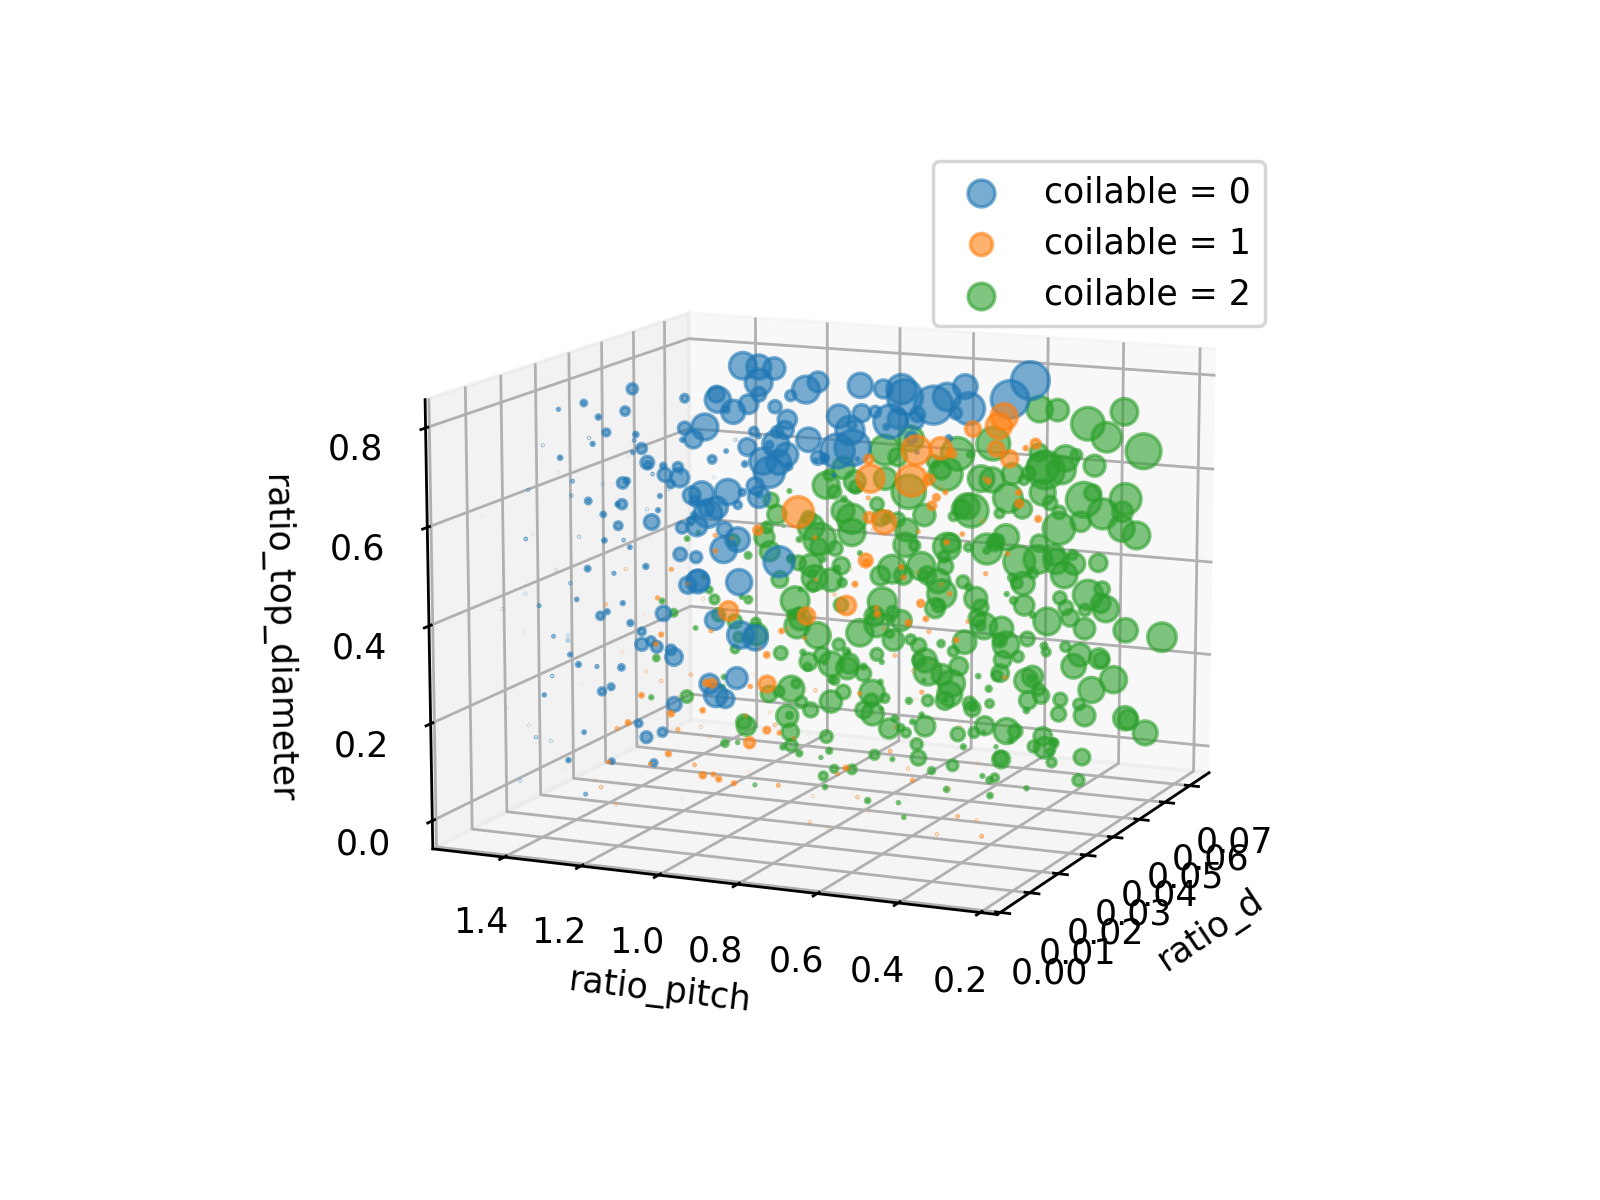

starting second scatter


<IPython.core.display.Javascript object>


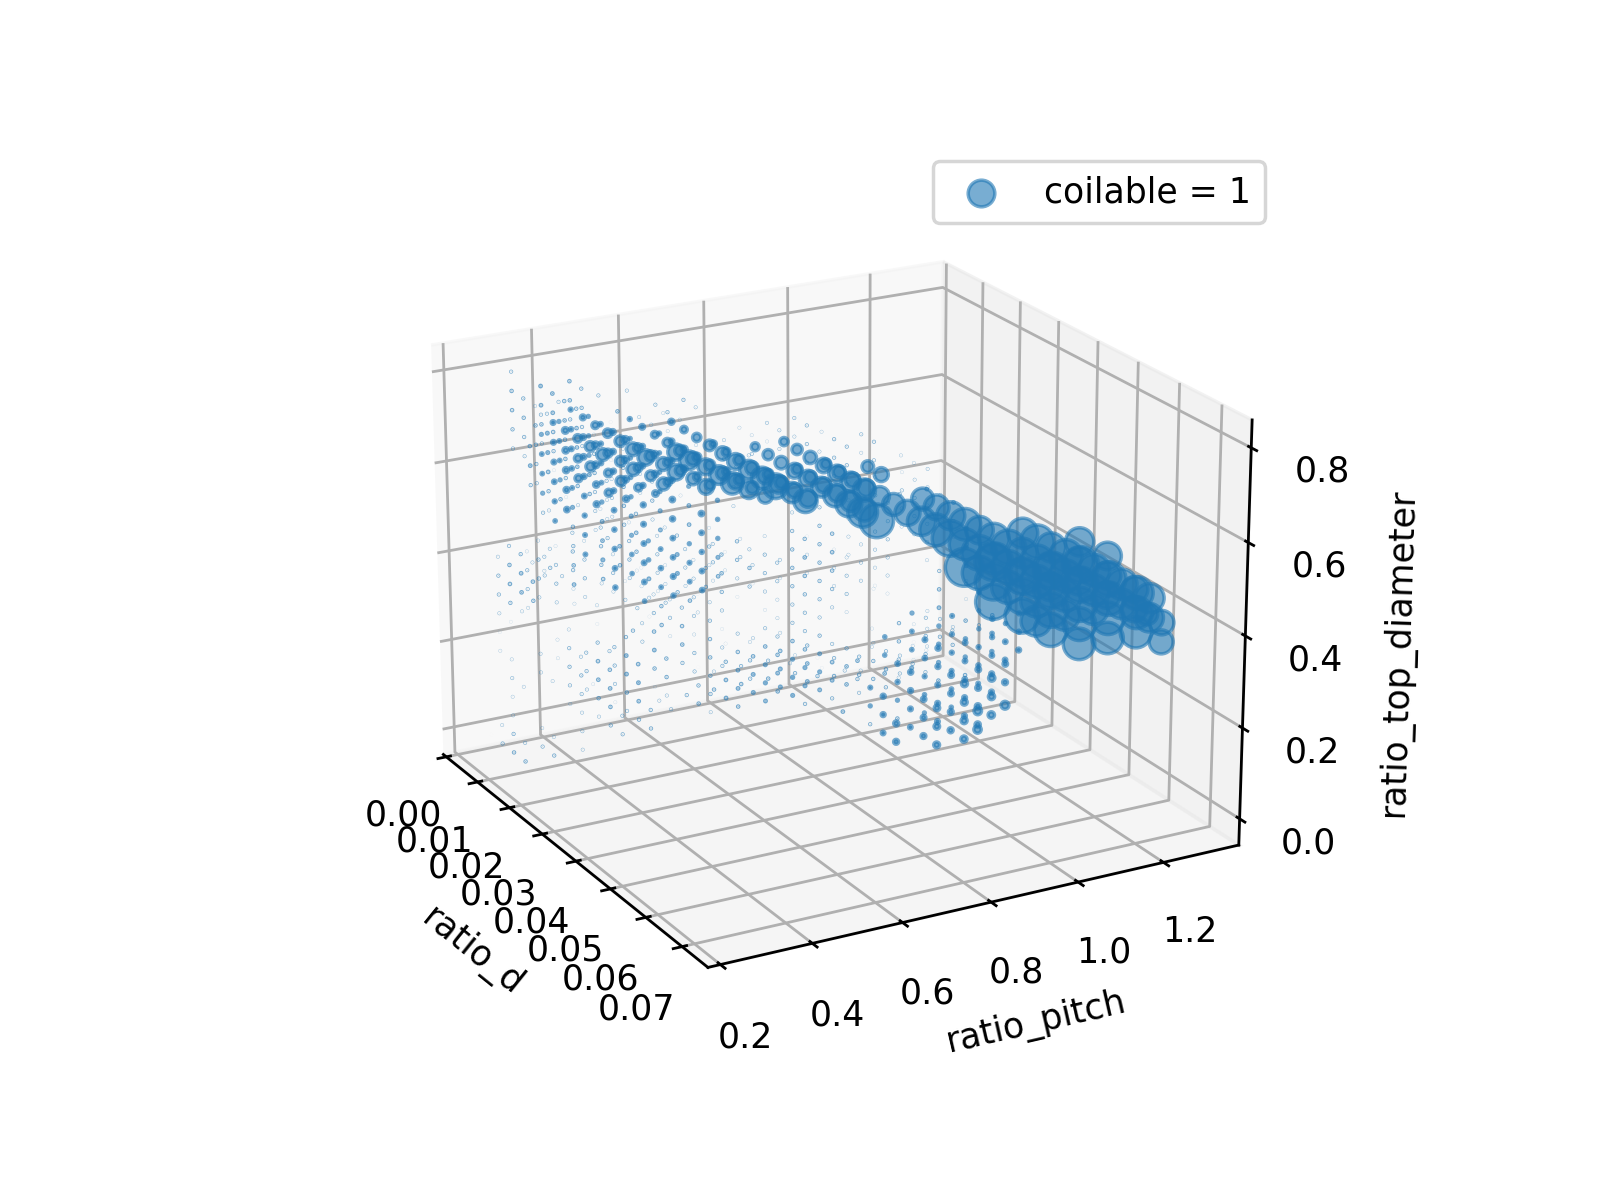

/Users/eaguerov/mambaforge/envs/3dasm/lib/python3.10/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


In [28]:
%matplotlib notebook
import matplotlib.pyplot as plt

def scatter_dataframe(input_df, output_df, color_column=-1, size_column=-1, sz = None, filter = False):
    """
    Scatter points from a DataFrame based on categorical labels.

    Parameters:
    df (pd.DataFrame): DataFrame with three input columns and one label column.
                       Label column values should be integers 0, 1, or 2.

    Returns:
    None
    """
    
    if sz != None:
        l = np.floor(sz*len(input_df))
        input_df = input_df[:int(l)]
        output_df = output_df[:int(l)]
    if filter == True:
        input_df = input_df[output_df.loc[:,color_column] == 1]
        output_df = output_df[output_df.loc[:,color_column] == 1]
        
    # Extract input columns and labels
    inputs = input_df #df.iloc[:, :3]
    labels = output_df.loc[:, color_column]
    sizes = output_df.loc[:, size_column].fillna(10)
    #sizes = sizes.apply(lambda x: 10 if x < 10 else x)

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    
    for label in sorted(labels.unique()):
        subset = inputs[labels == label]
        subset_sizes = sizes[labels == label]
        ax.scatter(subset.iloc[:, 0], subset.iloc[:, 1], subset.iloc[:, 2], 
                   s=subset_sizes, label=f'coilable = {label}', alpha=0.6)
    
    ax.set_xlabel(input_df.columns[0])
    ax.set_ylabel(input_df.columns[1])
    ax.set_zlabel(input_df.columns[2])
    plt.legend()
    plt.show()

A, B = data_csv.to_pandas()
arr1 = np.linspace(0.004, 0.072, 20)
arr2 = np.linspace(0.25, 1.5, 20)
arr3 = np.linspace(1e-7,  0.8, 20)
result = np.array(np.meshgrid(arr1, arr2, arr3)).T.reshape(-1, 3)
A2 = pd.DataFrame(result, columns=['ratio_d', 'ratio_pitch', 'ratio_top_diameter'])
B2 = pd.DataFrame()
B2['prediction_SVC'] = A2.apply(lambda row: predictor_SVC(row).item(), axis=1)
B2['prediction_GPR'] = A2.apply(lambda row: predictor_GPR(row).item(), axis=1)
scatter_dataframe(A, B, 
                  color_column='coilable', 
                  size_column='sigma_crit', sz=.75)
print("starting second scatter")
scatter_dataframe(A2, B2, 
                  color_column='prediction_SVC', 
                  size_column='prediction_GPR', filter=True)


In [44]:
input_3d, output_3d = data_csv.to_pandas()
output_3d['prediction'] = input_data_3d.apply(lambda row: predictor_GPR(row).item(), axis=1)
#print(output_3d)
print(mean_squared_error(output_3d['sigma_crit'], output_3d['prediction']))
print(output_3d.loc[:, ['coilable', 'sigma_crit', 'prediction']])
# scatter_dataframe(input_3d, output_3d 
#                   color_column='coilable', 
#                   size_column='sigma_crit', sz=.75)

print(input_3d[input_3d['ratio_d'] < 0.04])

#data_ML.evaluate(data_generator=predictor_SVC, output_names=['coilable'])
#data_ML.mark_all('open')
#data_ML.evaluate(data_generator=predictor_GPR, output_names=['sigma_crit'])
#print(data_ML)

1.0640594617952397
    coilable sigma_crit    prediction
0          1   0.000494  3.047259e-07
2          2  23.052002  2.298720e+01
3          0   0.693775  3.177975e-03
4          1   2.887962  2.006754e+00
5          0  36.699857  3.797918e+01
..       ...        ...           ...
994        2  25.601028  2.499766e+01
996        1    4.96869  3.998168e+00
997        2  50.932128  5.000697e+01
998        2  20.329816  1.999806e+01
999        0   0.095642 -5.804751e-04

[945 rows x 3 columns]
      ratio_d ratio_pitch ratio_top_diameter
0       0.004        0.25                0.0
3     0.02125      1.1875                0.6
4    0.029875     0.71875                0.5
7    0.012625     1.03125                0.3
8    0.016937    0.640625               0.75
..        ...         ...                ...
988  0.024552    0.585693           0.727344
991  0.007302    0.898193           0.127344
992  0.006224    0.605225           0.364844
996  0.032099    0.448975           0.664844
999  0

In [ ]:
output_data_3d['prediction'] = input_data_3d.apply(lambda row: predictor_SVC(row).item(), axis=1)

print(output_d3d[output_3d])
accuracy_score(output_data_3d['coilable'].astype(int), predictor_SVC(input_data_3d))